---
# Part A: Similarity and Anomalies

## A.1 Text Representation

There are two kinds of signal I can capture from petition text: semantic (what the petition is about) and lexical (what specific words it uses). For both similarity and anomaly detection, I need to choose which signal to pursue. Using the same signal for both methods risks a thin comparison, since both analyses would just be telling the same story from slightly different angles. That leaves two mixed combinations. I could do semantic anomaly detection with lexical similarity, which would find rare topics and common wording patterns. Or I could do semantic similarity with lexical anomaly detection, which finds common topics and unusual wording. The first combo is probably more interesting in theory, but the cases where those two perspectives overlap would be fewer and harder to interpret. Since the goal here is to give stakeholders a clear picture of what's typical and what's unusual in the petition landscape, semantic similarity and lexical anomaly is the better fit. Semantic similarity tells us what issues people commonly petition about, giving us a picture of the dominant concerns in public discourse. Lexical anomaly tells us which petitions are written in unusual ways, regardless of their topic. Comparing the two lets us ask things like: among petitions about common issues, do any stand out in how they're written? And among the lexical outliers, are they about mainstream topics or fringe ones? Because these two analyses rely on different kinds of signal, I will use two separate text representations to match: sentence embeddings for the similarity matching, and TF-IDF for the anomaly detection.

For TF-IDF, I set both min_df and max_df to 1 (effectively no filtering on either end). I already removed default spaCy stopwords and "government" as a domain-specific stopword during preprocessing, so there's no need for max_df to do additional filtering of common terms. On the other end, I deliberately keep all rare terms by not setting a min_df threshold, since the whole point of this representation is to feed into anomaly detection, and rare or unusual word usage is exactly the signal I want to preserve. I also leave max_features at None since ~11,000 documents is computationally manageable and I don't want to cap the vocabulary arbitrarily.

In [21]:
tfidf_vectorizer = TfidfVectorizer(
    min_df=1,
    max_df=1.0,
    max_features=None,
    ngram_range=(1, 1)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_no_stopwords'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (11092, 18261)


For the sentence embeddings, I use the all-MiniLM-L6-v2 model from the sentence-transformers library. It produces 384-dimensional dense vectors trained to place semantically similar sentences near each other in vector space. It's the standard starting point for this kind of semantic similarity task, it handles short-to-medium length text well (my concatenated petitions average ~115 words), and it's lightweight enough to run comfortably on ~11,000 documents.

In [22]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedding_model.encode(
    df['petition_concat'].tolist(),
    show_progress_bar=True,
    batch_size=64
)
print(f"Embeddings shape: {embeddings.shape}")

Batches: 100%|██████████| 174/174 [00:38<00:00,  4.51it/s]

Embeddings shape: (11092, 384)


## A.2 Dimensionality Reduction

I don't reduce dimensions on either representation. The sentence embeddings are only 384 dimensions, and since I'm using cosine similarity on them, that's totally manageable and there's no reason to compress further. The TF-IDF side is trickier. The matrix is 18000+ columns, and high dimensionality can mess with anomaly detection because distances between points start to blur together. But reducing dimensions here would mean throwing away rare words, which is exactly the signal I care about for finding lexical outliers. I don't feel that the tradeoff is worth it, so I'm not going to reduce the dimensions on the TF-IDF set. Because of that, my hand is basically forced into choosing Isolation Forest for the anomaly detection, as it isn't hurt by the sparse vector-space. That's not even really a con, Isolation Forest will give us the answers we want. 

## A.3 Similarity Analysis

The point of the similarity analysis is to figure out what topics people commonly petition about. What are the dominant concerns showing up across the dataset? To get at that, I compute pairwise cosine similarity on the sentence embeddings, which gives me a semantic similarity score between every pair of petitions.

My initial plan was to pull out cluster-like groupings from the similarity matrix: groups of petitions that are all highly similar to each other, representing shared topic areas. Per-document averages and top similar pairs felt too granular for what I was after. I wanted systematic similarity, not individual document scores.

To form those groups, I needed a similarity threshold for what counts as "about the same thing." I sampled pairs at various thresholds and found that 0.6 was where pairs actually started matching topically. Below that, pairs flagged as "similar" were really about unrelated issues.

With the threshold set, I tried two approaches to extract groups. First, connected components: treat petitions as nodes in a graph, draw edges where similarity >= 0.6, and find connected subgraphs. The problem was chaining. Petition A links to B, B to C, C to D, and so on, until 87% of the dataset ended up in a single giant component. That doesn't tell us anything useful. Second, I tried cliques, where every member of a group must be directly similar to every other member. This went the other direction: the algorithm found over 550,000 massively overlapping cliques, most of them sharing the same petitions. The underlying issue was that cosine similarity on sentence embeddings produces a continuous, moderately dense similarity landscape across the petition data. Trying to discretize that into neat groups via thresholding just doesn't work cleanly here.

So I'm going with per-document average similarity instead. For each petition, I compute its average cosine similarity to all other petitions. This gives a single score per document that captures how "mainstream" or "niche" a petition's topic is. Petitions with high average similarity are about issues that lots of other people also petition about. Petitions with low average similarity are about more unusual concerns. Crucially, this output is directly comparable to the Isolation Forest anomaly scores, which also produce a per-document score. That makes the comparison section straightforward: I can ask whether petitions that are lexically anomalous tend to be about mainstream or niche topics, and vice versa.

In [23]:
# Compute pairwise cosine similarity matrix on sentence embeddings
similarity_matrix = cosine_similarity(embeddings)
print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(f"Memory usage: {similarity_matrix.nbytes / 1e6:.0f}")

Similarity matrix shape: (11092, 11092)
Memory usage: 492


In [24]:
# Per-document average similarity (excluding self-similarity on diagonal)
n = similarity_matrix.shape[0]
avg_similarity = (similarity_matrix.sum(axis=1) - 1) / (n - 1)

print(f"Average similarity per document:")
print(f"  Mean:   {avg_similarity.mean():.4f}")
print(f"  Median: {np.median(avg_similarity):.4f}")
print(f"  Min:    {avg_similarity.min():.4f}")
print(f"  Max:    {avg_similarity.max():.4f}")
print(f"  Std:    {avg_similarity.std():.4f}")

Average similarity per document:
  Mean:   0.1829
  Median: 0.1853
  Min:    -0.0124
  Max:    0.3056
  Std:    0.0434


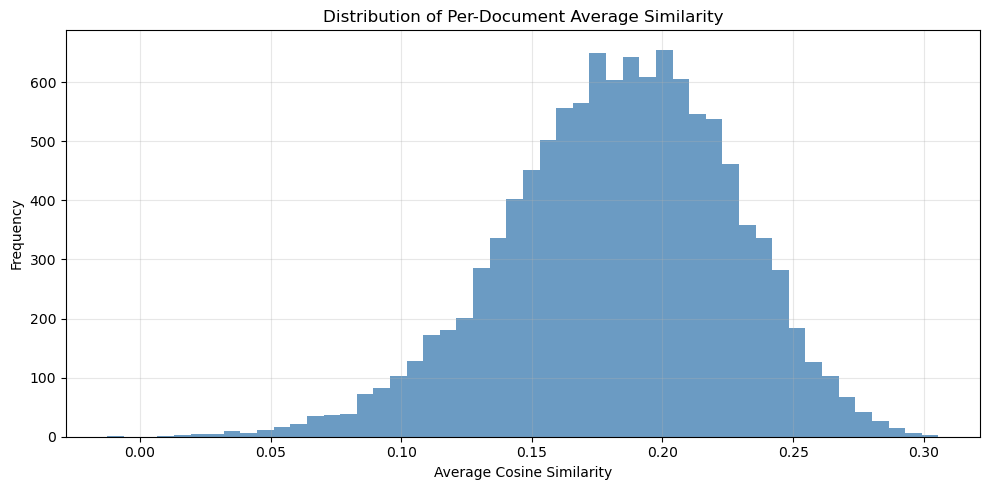

In [25]:
# Distribution of per-document average similarity
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(avg_similarity, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
ax.set_xlabel('Average Cosine Similarity')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Per-Document Average Similarity')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The distribution of average similarity scores is pretty compressed, ranging from roughly -0.01 to 0.31 with a standard deviation of only 0.04. Most petitions sit around 0.18, meaning the typical petition is weakly but consistently similar to the rest of the dataset. Nobody is dramatically more mainstream or more niche than anyone else.

The fact that this clustering happens at the low end of the 0-1 scale is worth noting. Petitions are broadly dissimilar to each other, which makes sense: people petition about all kinds of different things. But they're not completely unrelated either, there's a baseline of shared language and framing that comes from the petition format itself ("we want the government to...", "this would help..."). The max of 0.31 tells us that even the most "mainstream" petition is still not that similar to the average petition. And the min sitting just below zero means there are a few petitions that are genuinely unlike anything else in the dataset, semantically speaking. These are the ones I'll want to look at alongside the lexical anomalies later.

## A.4 Anomaly Detection

I'm using Isolation Forest on the TF-IDF vectors to detect lexically anomalous petitions. Isolation Forest works by randomly partitioning features with random splits, and the logic is that anomalies are easier to isolate (fewer splits needed) because they sit in sparse regions of the feature space. This is a good fit for the high-dimensional TF-IDF matrix because it splits on individual features rather than computing distances across the full space, so it doesn't suffer from the curse of dimensionality the way LOF or DBSCAN would.

I set contamination to 0.05. The similarity distribution showed a compressed range with a small lower tail, suggesting only a small minority of petitions are genuinely unusual. A lower contamination prioritizes precision: I'd rather flag fewer petitions and be confident they're actually anomalous than cast a wide net and pick up noise.

In [26]:
# Isolation Forest on TF-IDF vectors

iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=100
)

anomaly_labels = iso_forest.fit_predict(tfidf_matrix)
anomaly_scores = iso_forest.decision_function(tfidf_matrix)

# Separate structure: DataFrame with index, labels, scores
anomaly_df = pd.DataFrame({
    'index': range(len(anomaly_labels)),
    'label': anomaly_labels,        # 1 = normal, -1 = anomaly
    'score': anomaly_scores,         # lower = more anomalous
    'action': df['action'].values,
    'petition_concat': df['petition_concat'].values,
    'state': df['state'].values,
    'signature_count': df['signature_count'].values
})

n_anomalies = (anomaly_labels == -1).sum()
print(f"Anomalies flagged: {n_anomalies} ({n_anomalies/len(anomaly_labels)*100:.1f}%)")
print(f"Normal: {(anomaly_labels == 1).sum()}")
print(f"\nAnomaly score stats:")
print(f"  Mean:   {anomaly_scores.mean():.4f}")
print(f"  Min:    {anomaly_scores.min():.4f} (most anomalous)")
print(f"  Max:    {anomaly_scores.max():.4f} (most normal)")

Anomalies flagged: 555 (5.0%)
Normal: 10537

Anomaly score stats:
  Mean:   0.0104
  Min:    -0.0164 (most anomalous)
  Max:    0.0202 (most normal)


In [27]:
# Inspect the most anomalous petitions (lowest scores)
anomalies_only = anomaly_df[anomaly_df['label'] == -1].sort_values('score')

print("=== MOST ANOMALOUS (lowest scores) ===\n")
for _, row in anomalies_only.head(10).iterrows():
    print(f"Score: {row['score']:.4f} | State: {row['state']} | Sigs: {row['signature_count']}")
    print(f"Action: {row['action']}")
    print(f"Text: {row['petition_concat'][:300]}...")
    print()

print("\n=== LEAST ANOMALOUS among flagged (highest scores) ===\n")
for _, row in anomalies_only.tail(10).iterrows():
    print(f"Score: {row['score']:.4f} | State: {row['state']} | Sigs: {row['signature_count']}")
    print(f"Action: {row['action']}")
    print(f"Text: {row['petition_concat'][:300]}...")
    print()

=== MOST ANOMALOUS (lowest scores) ===

Score: -0.0164 | State: open | Sigs: 63
Action: Reassess CMS calculations to include assets and non-PAYE income for parents
Text: Reassess CMS calculations to include assets and non-PAYE income for parents We ask the Government to conduct a full review of Child Maintenance System calculation rules for parents who are self-employed or work outside the PAYE system. We request a modernised, transparent assessment framework reflec...

Score: -0.0164 | State: rejected | Sigs: 7
Action: Conduct a full investigation into the pakistani grooming gangs
Text: Conduct a full investigation into the pakistani grooming gangs We urge the Government to fully investigate Pakistani grooming gangs on behalf of UK Muslims.Justice for victims & addressing systemic failures in safeguarding is vital.A transparent inquiry will ensure accountability, support survivors,...

Score: -0.0154 | State: closed | Sigs: 10400
Action: Fund more staff training and better facilities 

Looking at the flagged anomalies, the pattern isn't one single thing. It's a mix of reasons petitions end up with rare vocabulary in the TF-IDF space:

Some use unusual formatting. The e-bike petition has bullet point characters (•) and list-style structure, which produce tokens most petitions don't have.
Some are loaded with technical jargon. The CMS petition uses "PAYE", "non-PAYE income", "assessment framework," which is bureaucratic language that rarely shows up elsewhere in the corpus.
Some pack in dense proper nouns and domain-specific terms, like the grooming gangs petition with "Pakistani grooming gangs", "safeguarding", "accountability" in a run-on style.
Some have unusual structure, like the civic responsibility petition which reads more like a policy document ("In three parts: 1)... 2)... 3)...") than a typical petition.

What they all share is that their word choices are rare relative to the rest of the corpus. Most petitions follow a fairly standard "we want the government to..." framing with common policy language. These ones break that mould in different ways, which is exactly what TF-IDF based anomaly detection should be picking up.

In [28]:
# Scatter plot: anomaly scores with anomalies highlighted
 
anomaly_df['label_name'] = anomaly_df['label'].map({1: 'Normal', -1: 'Anomaly'})
 
fig = px.scatter(
    anomaly_df,
    x='index',
    y='score',
    color='label_name',
    color_discrete_map={'Normal': 'steelblue', 'Anomaly': 'red'},
    hover_data=['action', 'state', 'signature_count'],
    title='Isolation Forest Anomaly Scores',
    labels={'index': 'Petition Index', 'score': 'Anomaly Score (lower = more anomalous)', 'label_name': ''},
    opacity=0.5
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=500)
fig.show()
 

Anomalous petitions appear randomly scatterd across petition index, which is a good sign. From the actions I can already see that anomalous petitions use far more specific nouns than non-anomalous petitions. That is intuitive since we chose a lexical measure. Petitions that have strange format, like bullet points or other would also be placed in anomalies, but I see very few here. Lets look at state and sig count on anomalous petitions to see if we can spot a pattern.

In [29]:
# Anomaly breakdown by state
anomalies_only = anomaly_df[anomaly_df['label'] == -1]
normal_only = anomaly_df[anomaly_df['label'] == 1]
 
print("=== State distribution ===")
print("\nAnomalies:")
print(anomalies_only['state'].value_counts(normalize=True).round(3))
print("\nNormal:")
print(normal_only['state'].value_counts(normalize=True).round(3))
 
print("\n=== Signature count stats ===")
print("\nAnomalies:")
print(anomalies_only['signature_count'].describe().round(1))
print("\nNormal:")
print(normal_only['signature_count'].describe().round(1))
 

=== State distribution ===

Anomalies:
state
rejected    0.550
closed      0.249
open        0.202
Name: proportion, dtype: float64

Normal:
state
rejected    0.555
closed      0.276
open        0.170
Name: proportion, dtype: float64

=== Signature count stats ===

Anomalies:
count       555.0
mean       2871.8
std       26337.4
min           6.0
25%           8.0
50%          21.0
75%         101.0
max      550137.0
Name: signature_count, dtype: float64

Normal:
count      10537.0
mean        1821.4
std        32441.0
min            4.0
25%            7.0
50%           21.0
75%           78.0
max      2984192.0
Name: signature_count, dtype: float64


Breaking down the anomalies by state and signature count, the distributions are basically identical to the normal petitions. Rejected petitions make up about 55% of both groups, and the signature stats are similar across the board. This suggests that lexical anomalies aren't picking up on some structural feature of the data like petition success or rejection. These petitions are anomalous purely in how they're written, not in their outcomes or popularity. My takeaway is that isolation forest is propperly flagging petitions with anomalous lexical patterns. 

## A.5 Comparison: Similarity vs. Anomaly Perspectives

The whole point of using two different signals was to see what each perspective reveals that the other doesn't. Now I want to look among lexical anomalies, and see if they about mainstream or niche topics, and also among the most semantically mainstream petitionsto see if any of those are written unusually. 

In [30]:
# Add average similarity to the anomaly dataframe for comparison
anomaly_df['avg_similarity'] = avg_similarity

# Question 1: Among lexical anomalies, what's their semantic similarity profile?
print("=== Avg similarity: anomalies vs normal ===\n")
print("Anomalies:")
print(anomaly_df[anomaly_df['label'] == -1]['avg_similarity'].describe().round(4))
print("\nNormal:")
print(anomaly_df[anomaly_df['label'] == 1]['avg_similarity'].describe().round(4))

=== Avg similarity: anomalies vs normal ===

Anomalies:
count    555.0000
mean       0.1921
std        0.0415
min        0.0551
25%        0.1638
50%        0.1956
75%        0.2225
max        0.2858
Name: avg_similarity, dtype: float64

Normal:
count    10537.0000
mean         0.1825
std          0.0434
min         -0.0124
25%          0.1544
50%          0.1849
75%          0.2137
max          0.3056
Name: avg_similarity, dtype: float64


In [31]:
# Question 2: Among the most semantically mainstream petitions (top 5% avg similarity),
# how many are lexically anomalous?
top_5_pct = np.percentile(avg_similarity, 95)
mainstream = anomaly_df[anomaly_df['avg_similarity'] >= top_5_pct]

n_mainstream_anomalies = (mainstream['label'] == -1).sum()
n_mainstream_total = len(mainstream)

print(f"=== Mainstream petitions (top 5% avg similarity, >= {top_5_pct:.4f}) ===\n")
print(f"Total: {n_mainstream_total}")
print(f"Flagged as lexical anomalies: {n_mainstream_anomalies} ({n_mainstream_anomalies/n_mainstream_total*100:.1f}%)")

if n_mainstream_anomalies > 0:
    print(f"\nThese mainstream-but-anomalous petitions:")
    for _, row in mainstream[mainstream['label'] == -1].iterrows():
        print(f"\n  Score: {row['score']:.4f} | Avg sim: {row['avg_similarity']:.4f} | Sigs: {row['signature_count']}")
        print(f"  Action: {row['action']}")
        print(f"  Text: {row['petition_concat'][:300]}...")

=== Mainstream petitions (top 5% avg similarity, >= 0.2487) ===

Total: 555
Flagged as lexical anomalies: 38 (6.8%)

These mainstream-but-anomalous petitions:

  Score: -0.0005 | Avg sim: 0.2508 | Sigs: 7
  Action: Properly address and stop the shortage of vets in the UK
  Text: Properly address and stop the shortage of vets in the UK In a 21st century Britain, NO ONE, animal or human, should be denied help and care simply because of staff shortages, brought on by the failed promises of a past government. This is a national issue that CANNOT go on any longer like this! A fu...

  Score: -0.0013 | Avg sim: 0.2775 | Sigs: 346
  Action: Reform the Public Health Act to prevent future lockdowns without MP's scrutiny
  Text: Reform the Public Health Act to prevent future lockdowns without MP's scrutiny Replace emergency procedures in the Public Health Act 1984 (including the section 45R, the urgency procedure that allows a single minister to implement emergency legislation), with revised leg

The two analyses pick up different things. That's kind of the whole point. Lexical anomalies actually have a slightly higher average semantic similarity (0.192) than normal petitions (0.183), which, if anything, means the weird-sounding ones are about more normal stuff. Also, if you look at the top 5% most semantically mainstream petitions, 6.8% of them are lexical anomalies, which is above the 5% base rate. So yeah. Mainstream topics attract more unusual writing. Not the other way around.

Basically semantic similarity and lexical anomaly are just measuring different things. Writing weird doesn't mean you're writing about weird stuff. The anomalous petitions aren't like, unhinged rants about niche conspiracy topics. They're about animal welfare and the NHS and school fees and buses. Normal stuff. They just happen to use technical language or strange formatting or read like policy documents instead of starting with "we want the government to..." The two signals don't really overlap, which is why using both was worth it anyway. 